# FM-1.3 Token Length Analysis

Compares trace token lengths (cl100k_base tokenizer) for **FM-1.3 (step repetition)** vs **non-FM-1.3** traces,
broken down per framework, using the full MAD HuggingFace dataset (1 242 traces).

In [ ]:
import json
import tiktoken
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from scipy import stats

DATA_PATH = Path("../MAD_full_dataset.json")

with open(DATA_PATH) as f:
    records = json.load(f)

print(f"Loaded {len(records)} traces")

In [3]:
enc = tiktoken.get_encoding("cl100k_base")
print("Tokenizer loaded: cl100k_base")

Tokenizer loaded: cl100k_base


In [4]:
def count_tokens(text: str) -> int:
    return len(enc.encode(text))


rows = []
for rec in records:
    trajectory = rec["trace"]["trajectory"]
    text = trajectory if isinstance(trajectory, str) else json.dumps(trajectory)
    n_tokens = count_tokens(text)
    rows.append({
        "framework": rec["mas_name"],
        "trace_id":  rec["trace"]["key"],
        "fm13":      bool(rec["mast_annotation"].get("1.3", 0)),
        "n_tokens":  n_tokens,
    })

df = pd.DataFrame(rows)
print(df.shape)
df.head()

(1242, 4)


,framework,trace_id,fm13,n_tokens
0,ChatDev,ChatDev_ProgramDev_GPT4o,False,85116
1,ChatDev,ChatDev_ProgramDev_GPT4o,False,80444
2,ChatDev,ChatDev_ProgramDev_GPT4o,False,69211
3,ChatDev,ChatDev_ProgramDev_GPT4o,False,57986
4,ChatDev,ChatDev_ProgramDev_GPT4o,False,93408


In [5]:
FRAMEWORKS = sorted(df["framework"].unique())
COLORS = {True: "#d62728", False: "#1f77b4"}   # red = FM-1.3, blue = non-FM-1.3

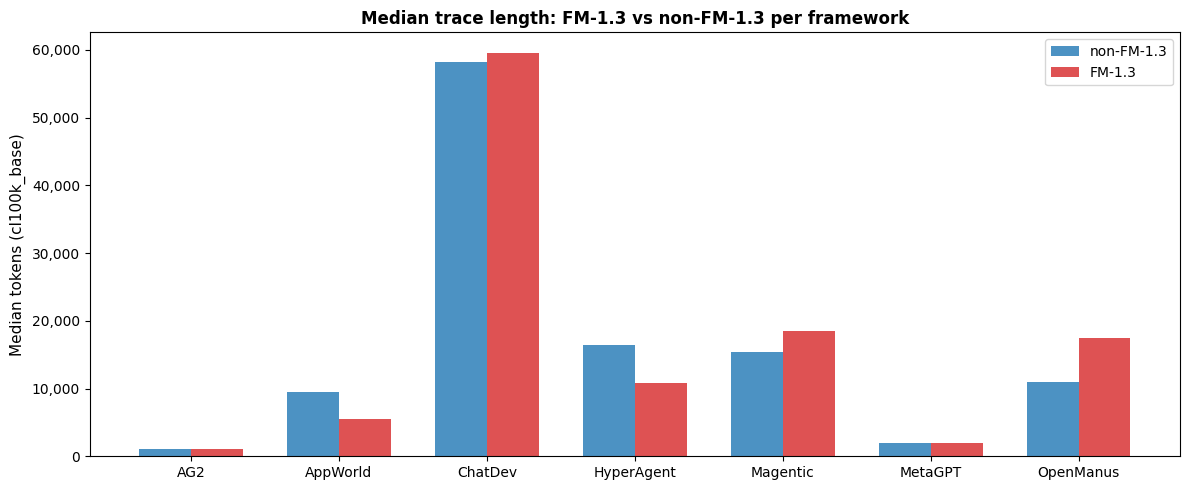

In [6]:
# Median token count bar chart per framework
medians = (
    df.groupby(["framework", "fm13"])["n_tokens"]
    .median()
    .unstack("fm13")
    .rename(columns={False: "non-FM-1.3", True: "FM-1.3"})
    .reindex(FRAMEWORKS)
)

x = np.arange(len(FRAMEWORKS))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, medians["non-FM-1.3"], width, label="non-FM-1.3", color=COLORS[False], alpha=0.8)
ax.bar(x + width/2, medians["FM-1.3"],     width, label="FM-1.3",     color=COLORS[True],  alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(FRAMEWORKS, fontsize=10)
ax.set_ylabel("Median tokens (cl100k_base)", fontsize=11)
ax.set_title("Median trace length: FM-1.3 vs non-FM-1.3 per framework", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{int(y):,}"))
ax.legend()
plt.tight_layout()
plt.savefig("fm13_median_tokens_per_framework.png", dpi=150, bbox_inches="tight")
plt.show()

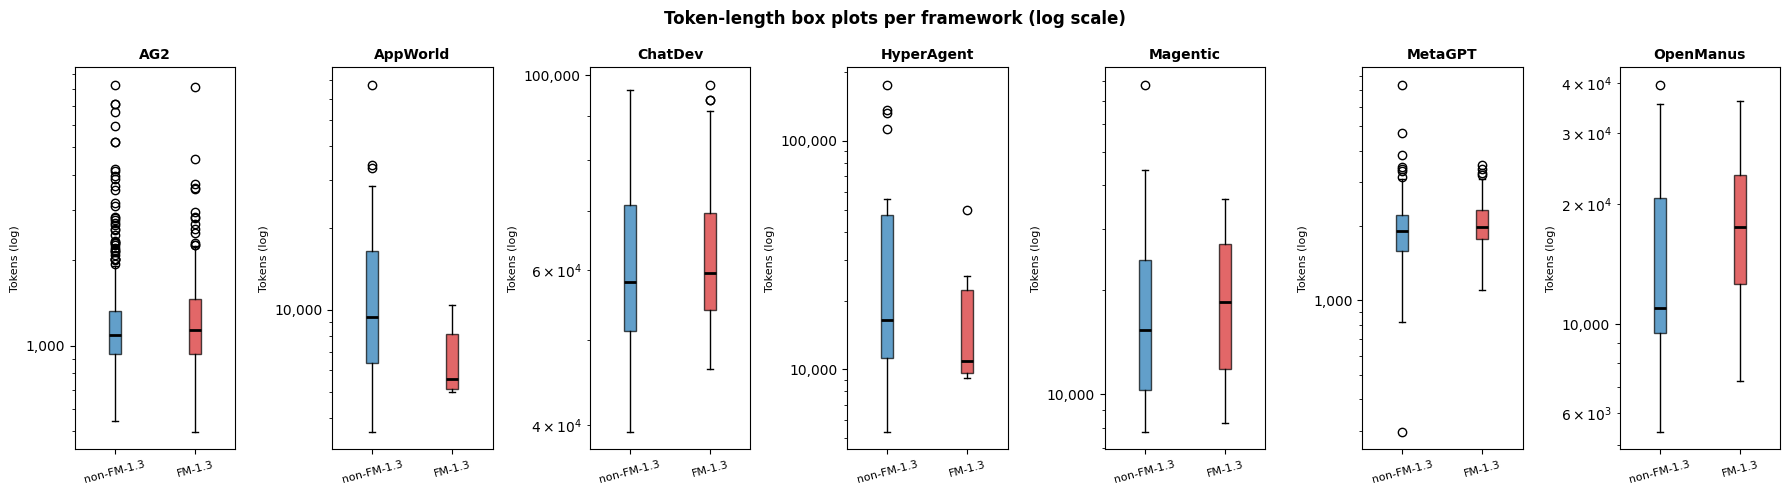

In [7]:
# Box-plots per framework (log scale to handle wide spread)
fig, axes = plt.subplots(1, len(FRAMEWORKS), figsize=(18, 5), sharey=False)

for ax, fw in zip(axes, FRAMEWORKS):
    grp = df[df["framework"] == fw]
    data_to_plot = [grp.loc[~grp["fm13"], "n_tokens"].values,
                    grp.loc[grp["fm13"],  "n_tokens"].values]
    bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                    medianprops={"color": "black", "linewidth": 2})
    for patch, color in zip(bp["boxes"], [COLORS[False], COLORS[True]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["non-FM-1.3", "FM-1.3"], fontsize=8, rotation=15)
    ax.set_title(fw, fontsize=10, fontweight="bold")
    ax.set_yscale("log")
    ax.set_ylabel("Tokens (log)", fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{int(y):,}"))

fig.suptitle("Token-length box plots per framework (log scale)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fm13_boxplots_per_framework.png", dpi=150, bbox_inches="tight")
plt.show()